# ResNet-18

## Changes from Naive Baseline

### What changed
| | Naive | Unfreeze |
|---|---|---|
| Backbone | Frozen (only FC trains) | Unfrozen (all layers train) |
| Optimizer scope | `model.fc.parameters()` | `model.parameters()` |
| Learning rate | `1e-3` | `1e-4` |

### Rationale
In the naive version, the ResNet backbone was frozen — only the final classification layer (513 parameters out of ~11M) was trained. The backbone weights were fixed at ImageNet features, which are general-purpose and not specific to skin lesions.

By unfreezing the backbone, all ~11M parameters are fine-tuned on the HAM10000 dataset, allowing the model to adapt its feature extraction to the medical imaging domain.

A lower learning rate (`1e-4`) is used to avoid destroying the pretrained weights with large gradient updates early in training — the goal is to make small, careful adjustments to already-useful features rather than learning from scratch.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [2]:
use_mps = True
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('mps' if (use_mps and torch.backends.mps.is_available()) else 'cpu')
print(f'Using device: {device}')

MPS available: True
Using device: mps


In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../data/splits/train.csv',
    val_csv='../data/splits/val.csv',
    test_csv='../data/splits/test.csv',
    image_dir='../data/raw/HAM10000/images',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('../data/splits/train.csv')

num_melanoma = (train_df['label'] == 0).sum()   # melanoma in CSV
num_nevus = (train_df['label'] == 1).sum()      # nevus in CSV

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Positive weight: tensor([6.0244], device='mps:0')


In [4]:
best_val_f2 = 0.0

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), '../models/resnet_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.6957, Acc: 0.7811, Recall: 0.8498, F2: 0.6812 | Val Loss: 0.6061, Acc: 0.8167, Recall: 0.8922, F2: 0.7347
Saved best model at epoch 1
Epoch [2/20] | Train Loss: 0.5241, Acc: 0.8527, Recall: 0.8947, F2: 0.7681 | Val Loss: 0.6979, Acc: 0.8934, Recall: 0.6587, F2: 0.6501
Epoch [3/20] | Train Loss: 0.4446, Acc: 0.8792, Recall: 0.9166, F2: 0.8066 | Val Loss: 0.6550, Acc: 0.8917, Recall: 0.7605, F2: 0.7200
Epoch [4/20] | Train Loss: 0.3970, Acc: 0.8905, Recall: 0.9332, F2: 0.8280 | Val Loss: 0.8661, Acc: 0.8755, Recall: 0.6707, F2: 0.6429
Epoch [5/20] | Train Loss: 0.3449, Acc: 0.9050, Recall: 0.9320, F2: 0.8424 | Val Loss: 0.6114, Acc: 0.8679, Recall: 0.8563, F2: 0.7590
Saved best model at epoch 5
Epoch [6/20] | Train Loss: 0.2641, Acc: 0.9313, Recall: 0.9564, F2: 0.8863 | Val Loss: 0.6152, Acc: 0.9054, Recall: 0.7904, F2: 0.7534
Epoch [7/20] | Train Loss: 0.2503, Acc: 0.9359, Recall: 0.9589, F2: 0.8931 | Val Loss: 0.8184, Acc: 0.8977, Recall: 0.7365, F2: 0.7093

## Plot Loss and Accuracy Curves

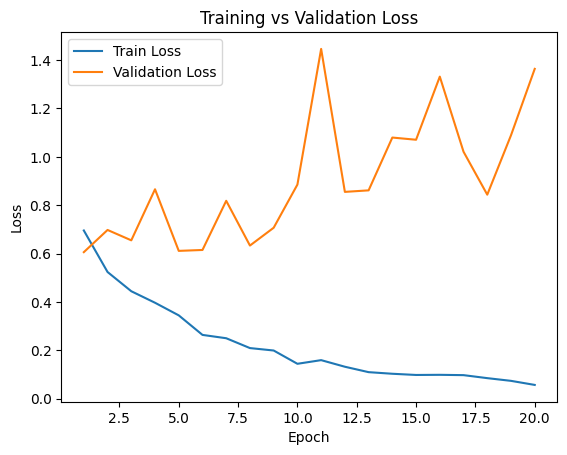

In [5]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

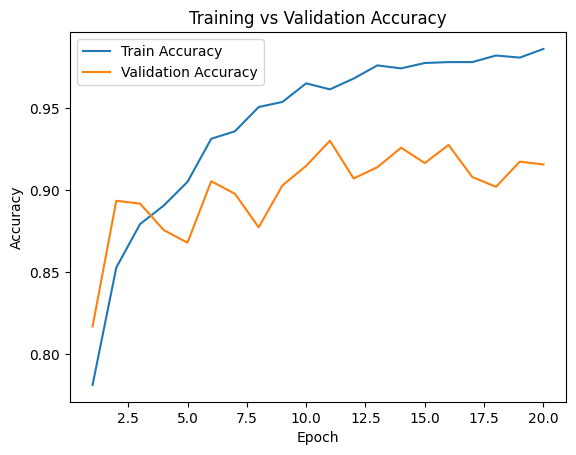

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

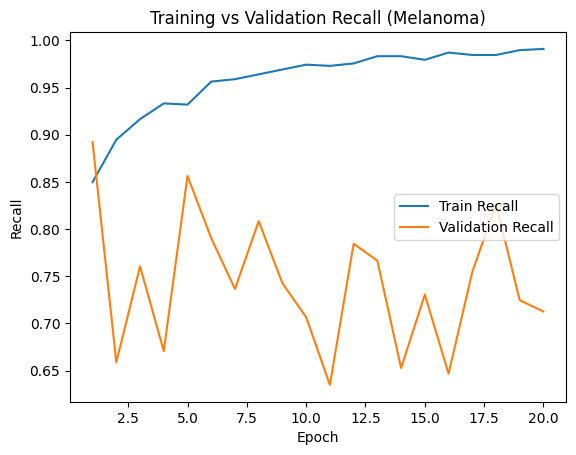

In [7]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

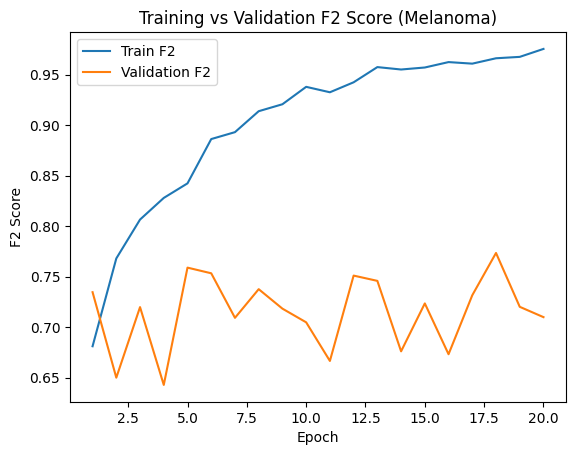

In [8]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [9]:
import numpy as np
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load('../models/resnet_best.pth', map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Best threshold: 0.31 | Val F2: 0.7797


In [10]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [11]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[922  84]
 [ 17 150]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [12]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9819    0.9165    0.9481      1006
           1     0.6410    0.8982    0.7481       167

    accuracy                         0.9139      1173
   macro avg     0.8115    0.9074    0.8481      1173
weighted avg     0.9334    0.9139    0.9196      1173



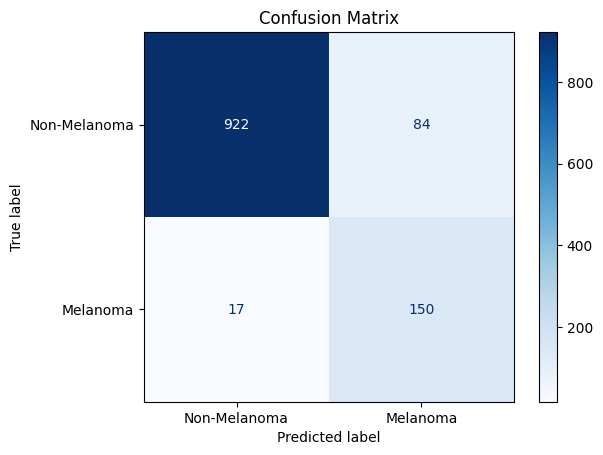

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()